# First pipeline: final model evaluation
Run the pipeline to refresh train/test data, select a model using 2019 validation accuracy, and refit on the training data. Then evaluate the returned model on TEST_TRAIN/test.csv. Running the pipeline downloads source data and rewrites the train/test CSVs.

In [2]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression

project_root = Path.cwd()
if not (project_root / "Run Pipeline").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "Run Pipeline"))
from run_pipeline import run_pipeline

%matplotlib inline

In [3]:
final_model = run_pipeline()

c:\Users\jonny\PycharmProjects\Election Prediction 12.08\.venv\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [4]:
# Read after the pipeline finishes so this is the refreshed test dataset.
test_data = pd.read_csv(project_root / "TEST_TRAIN" / "test.csv")
feature_columns = list(final_model.feature_names_in_)
required_columns = ["winner"]
# Logistic regression requires complete predictors; the other models handle gaps.
if isinstance(final_model.named_steps["classifier"], LogisticRegression):
    required_columns += feature_columns

evaluation_data = test_data.dropna(subset=required_columns).copy()
if evaluation_data.empty:
    raise ValueError("No test rows are available for evaluation.")

predictions = final_model.predict(evaluation_data[feature_columns])
evaluation_data["predicted_winner"] = predictions
print(f"Evaluated {len(evaluation_data)} of {len(test_data)} test rows; "
      f"excluded {len(test_data) - len(evaluation_data)} rows with missing required values.")
print(f"Test accuracy: {accuracy_score(evaluation_data['winner'], predictions):.2%}")
evaluation_data[["constituency_name", "election", "winner", "predicted_winner"]].head()

Evaluated 632 of 632 test rows; excluded 0 rows with missing required values.
Test accuracy: 55.06%


,constituency_name,election,winner,predicted_winner
0,Aldershot,2024,lab,con
1,Aldridge-Brownhills,2024,con,con
2,Altrincham and Sale West,2024,lab,con
3,Amber Valley,2024,lab,con
4,Arundel and South Downs,2024,con,con


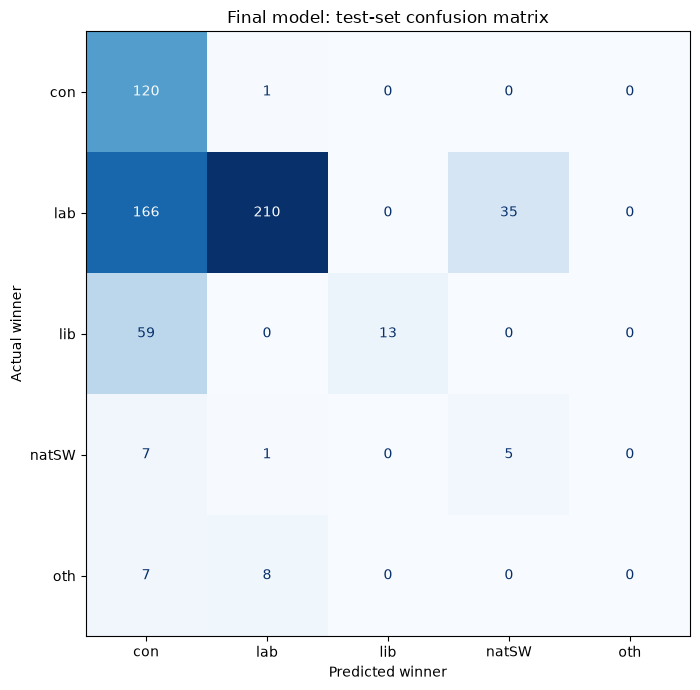

In [5]:
# Include all true and predicted classes, even parties absent from training.
labels = sorted(set(evaluation_data["winner"]) | set(predictions))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    evaluation_data["winner"], predictions,
    labels=labels, display_labels=labels,
    cmap="Blues", values_format="d", ax=ax, colorbar=False,
)
ax.set_title("Final model: test-set confusion matrix")
ax.set_xlabel("Predicted winner")
ax.set_ylabel("Actual winner")
fig.tight_layout()
plt.show()